# Using Pandas and Python to Explore Your Dataset

**Table of Content**

1. [Using the pandas Python Library](#sec1)
2. [Getting to Know Your Data](#sec2)
3. [Getting to Know pandas’ Data Structures](#sec3)
4. [Accessing Series Elements](#sec4)
5. [Accessing DataFrame Elements](#sec5)
6. [Querying Your Dataset](#sec6)
7. [Grouping and Aggregating Your Data](#sec7)
8. [Manipulating Columns](#sec8)
9. [Sorting by one or more columns](#sec9)
10. [Indexing and Slicing](#sec10)


<a id="sec1"></a>

## 1. Using the pandas Python Library

In [1]:
import requests

download_url = "https://raw.githubusercontent.com/fivethirtyeight/data/master/nba-elo/nbaallelo.csv"
target_csv_path = "nba_all_elo.csv"

response = requests.get(download_url)
response.raise_for_status()    # Check that the request was successful
with open(target_csv_path, "wb") as f:
    f.write(response.content)
print("Download ready.")

Download ready.


In [2]:
import pandas as pd
nba = pd.read_csv("nba_all_elo.csv")
type(nba)

pandas.core.frame.DataFrame

In [3]:
len(nba)

nba.shape

(126314, 23)

In [4]:
nba.head()

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,...,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,...,40.294830,NYK,Knicks,68,1300.0000,1306.7233,H,L,0.640065,NaN
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,...,41.705170,TRH,Huskies,66,1300.0000,1293.2767,A,W,0.359935,NaN
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,...,42.012257,NYK,Knicks,47,1306.7233,1297.0712,H,W,0.631101,NaN
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,...,40.692783,CHS,Stags,63,1300.0000,1309.6521,A,L,0.368899,NaN
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,...,38.864048,WSC,Capitols,50,1300.0000,1320.3811,H,L,0.640065,NaN


In [5]:
pd.set_option("display.max.columns", None)

In [6]:
nba.tail()

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,elo_i,elo_n,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes
126309,63155,201506110CLE,NBA,0,2015,6/11/2015,100,1,CLE,Cavaliers,82,1723.4149,1704.3949,60.309792,GSW,Warriors,103,1790.9591,1809.9791,H,L,0.546572,NaN
126310,63156,201506140GSW,NBA,0,2015,6/14/2015,102,1,GSW,Warriors,104,1809.9791,1813.6349,68.013329,CLE,Cavaliers,91,1704.3949,1700.7391,H,W,0.765565,NaN
126311,63156,201506140GSW,NBA,1,2015,6/14/2015,101,1,CLE,Cavaliers,91,1704.3949,1700.7391,60.010067,GSW,Warriors,104,1809.9791,1813.6349,A,L,0.234435,NaN
126312,63157,201506170CLE,NBA,0,2015,6/16/2015,102,1,CLE,Cavaliers,97,1700.7391,1692.0859,59.290245,GSW,Warriors,105,1813.6349,1822.2881,H,L,0.481450,NaN
126313,63157,201506170CLE,NBA,1,2015,6/16/2015,103,1,GSW,Warriors,105,1813.6349,1822.2881,68.519516,CLE,Cavaliers,97,1700.7391,1692.0859,A,W,0.518550,NaN


<a id="sec2"></a>

## 2. Getting to Know Your Data

In [7]:
nba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126314 entries, 0 to 126313
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   gameorder      126314 non-null  int64  
 1   game_id        126314 non-null  object 
 2   lg_id          126314 non-null  object 
 3   _iscopy        126314 non-null  int64  
 4   year_id        126314 non-null  int64  
 5   date_game      126314 non-null  object 
 6   seasongame     126314 non-null  int64  
 7   is_playoffs    126314 non-null  int64  
 8   team_id        126314 non-null  object 
 9   fran_id        126314 non-null  object 
 10  pts            126314 non-null  int64  
 11  elo_i          126314 non-null  float64
 12  elo_n          126314 non-null  float64
 13  win_equiv      126314 non-null  float64
 14  opp_id         126314 non-null  object 
 15  opp_fran       126314 non-null  object 
 16  opp_pts        126314 non-null  int64  
 17  opp_elo_i      126314 non-nul

In [8]:
nba.describe()

,gameorder,_iscopy,year_id,seasongame,is_playoffs,pts,elo_i,elo_n,win_equiv,opp_pts,opp_elo_i,opp_elo_n,forecast
count,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000,126314.000000
mean,31579.000000,0.500000,1988.200374,43.533733,0.063857,102.729982,1495.236055,1495.236055,41.707889,102.729982,1495.236055,1495.236055,0.500000
std,18231.927643,0.500002,17.582309,25.375178,0.244499,14.814845,112.139945,112.461687,10.627332,14.814845,112.139945,112.461687,0.215252
min,1.000000,0.000000,1947.000000,1.000000,0.000000,0.000000,1091.644500,1085.774400,10.152501,0.000000,1091.644500,1085.774400,0.020447
25%,15790.000000,0.000000,1975.000000,22.000000,0.000000,93.000000,1417.237975,1416.994900,34.103035,93.000000,1417.237975,1416.994900,0.327989
50%,31579.000000,0.500000,1990.000000,43.000000,0.000000,103.000000,1500.945550,1500.954400,42.113357,103.000000,1500.945550,1500.954400,0.500000
75%,47368.000000,1.000000,2003.000000,65.000000,0.000000,112.000000,1576.060000,1576.291625,49.635328,112.000000,1576.060000,1576.291625,0.672011
max,63157.000000,1.000000,2015.000000,108.000000,1.000000,186.000000,1853.104500,1853.104500,71.112038,186.000000,1853.104500,1853.104500,0.979553


In [9]:
import numpy as np
nba.describe(include=object)

,game_id,lg_id,date_game,team_id,fran_id,opp_id,opp_fran,game_location,game_result,notes
count,126314,126314,126314,126314,126314,126314,126314,126314,126314,5424
unique,63157,2,12426,104,53,104,53,3,2,231
top,194611010TRH,NBA,4/13/2011,BOS,Lakers,BOS,Lakers,H,L,at New York NY
freq,2,118016,30,5997,6024,5997,6024,63138,63157,440


#### EDA

In [10]:
nba["team_id"].value_counts()

nba["fran_id"].value_counts()

fran_id
Lakers          6024
Celtics         5997
Knicks          5769
Warriors        5657
Pistons         5650
Sixers          5644
Hawks           5572
Kings           5475
Wizards         4582
Spurs           4309
Bulls           4307
Pacers          4227
Thunder         4178
Rockets         4154
Nuggets         4120
Nets            4106
Suns            4080
Bucks           4034
Trailblazers    3870
Cavaliers       3810
Clippers        3733
Jazz            3555
Mavericks       3013
Heat            2371
Pelicans        2254
Magic           2207
Timberwolves    2131
Grizzlies       1657
Raptors         1634
Hornets          894
Colonels         846
Squires          799
Spirits          777
Stars            756
Sounds           697
Baltimore        467
Floridians       440
Condors          430
Capitols         291
Olympians        282
Sails            274
Stags            260
Bombers          249
Steamrollers     168
Packers           72
Redskins          65
Rebels            63
Water

In [13]:
nba.loc[nba["fran_id"] == "Lakers", "team_id"].value_counts() #Other lakers team

team_id
LAL    5078
MNL     946
Name: count, dtype: int64

You can even find out when they played those games. For that, you’ll first define a column that converts the value of date_game to the datetime data type. Then you can use the min and max aggregate functions, to find the first and last games of Minneapolis Lakers:

In [12]:
nba["date_played"] = pd.to_datetime(nba["date_game"])
nba.loc[nba["team_id"] == "MNL", "date_played"].min()

nba.loc[nba['team_id'] == 'MNL', 'date_played'].max()

nba.loc[nba["team_id"] == "MNL", "date_played"].agg(("min", "max"))

min   1948-11-04
max   1960-03-26
Name: date_played, dtype: datetime64[ns]

<a id="sec3"></a>

## 3. Getting to Know pandas’ Data Structures

#### Understanding Series objects

Series object wraps two components:

1. A sequence of values
2. A sequence of identifiers, which is the index

In [14]:
revenues = pd.Series([5555, 7000, 1980])
revenues

0    5555
1    7000
2    1980
dtype: int64

In [15]:
revenues.values

revenues.index

RangeIndex(start=0, stop=3, step=1)

In [16]:
city_revenues = pd.Series(
    [4200, 8000, 6500],
    index=["Amsterdam", "Toronto", "Tokyo"]
)
city_revenues

Amsterdam    4200
Toronto      8000
Tokyo        6500
dtype: int64

You can use the code blocks above to distinguish between two types of Series:

1. revenues: This Series behaves like a Python list because it only has a positional index.
2. city_revenues: This Series acts like a Python dictionary because it features both a positional and a label index.

In [17]:
city_employee_count = pd.Series({"Amsterdam": 5, "Tokyo": 8})
city_employee_count

Amsterdam    5
Tokyo        8
dtype: int64

Also supports .keys() and "in" keyword like dictionaries

In [18]:
city_employee_count.keys()

"Tokyo" in city_employee_count

"New York" in city_employee_count

False

#### Understanding DataFrame Objects

In [19]:
city_data = pd.DataFrame({
    "revenue": city_revenues,
    "employee_count": city_employee_count
})
city_data

,revenue,employee_count
Amsterdam,4200,5.0
Tokyo,6500,8.0
Toronto,8000,NaN


The new DataFrame index is the union of the two Series indices:

In [20]:
city_data.index

Index(['Amsterdam', 'Tokyo', 'Toronto'], dtype='object')

In [21]:
city_data.axes


city_data.axes[0]

city_data.axes[1]

Index(['revenue', 'employee_count'], dtype='object')

<a id="sec4"></a>

## 4. Accessing Series Elements

You’ll also learn how to use two pandas-specific access methods:

1. .loc
2. .iloc

In [22]:
city_revenues

Amsterdam    4200
Toronto      8000
Tokyo        6500
dtype: int64

In [23]:
city_revenues["Toronto"]

city_revenues[1]

/var/folders/_n/qn6k7dzj7_398pb0gxf3_2h80000gn/T/ipykernel_98157/2885618142.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  city_revenues[1]


np.int64(8000)

In [24]:
colors = pd.Series(
    ["red", "purple", "blue", "green", "yellow"],
    index=[1, 2, 3, 5, 8]
)
colors

1       red
2    purple
3      blue
5     green
8    yellow
dtype: object

In [25]:
colors.loc[1]

colors.iloc[1]

'purple'

.loc points to the label index; .iloc points to the positional index 

In [26]:
# Return the elements with the implicit index: 1, 2
colors.iloc[1:3]

2    purple
3      blue
dtype: object

In [27]:
# Return the elements with the explicit index between 3 and 8
colors.loc[3:8]

3      blue
5     green
8    yellow
dtype: object

In [28]:
colors.iloc[-2]

'green'

<a id="sec5"></a>

## 5. Accessing DataFrame Elements


#### Index Operator

In [29]:
city_data["revenue"]

type(city_data["revenue"])

pandas.core.series.Series

In [ ]:
city_data.revenue #col name

Amsterdam    4200
Tokyo        6500
Toronto      8000
Name: revenue, dtype: int64

In [31]:
toys = pd.DataFrame([
    {"name": "ball", "shape": "sphere"},
    {"name": "Rubik's cube", "shape": "cube"}
])
toys["shape"]



toys.shape

(2, 2)

with .loc and .iloc:

In [32]:
city_data.loc["Amsterdam"]



city_data.loc["Tokyo": "Toronto"]



city_data.iloc[1]

revenue           6500.0
employee_count       8.0
Name: Tokyo, dtype: float64

In [33]:
city_data.loc["Amsterdam": "Tokyo", "revenue"]

Amsterdam    4200
Tokyo        6500
Name: revenue, dtype: int64

<a id="sec6"></a>

## 6. Querying Your Dataset


In [34]:
current_decade = nba[nba["year_id"] > 2010]
current_decade.shape

(12658, 24)

In [35]:
games_with_notes = nba[nba["notes"].notnull()]
games_with_notes.shape

(5424, 24)

In [36]:
ers = nba[nba["fran_id"].str.endswith("ers")]
ers.shape

(27797, 24)

In [37]:
nba[
    (nba["_iscopy"] == 0) &
    (nba["pts"] > 100) &
    (nba["opp_pts"] > 100) &
    (nba["team_id"] == "BLB")
]

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,elo_i,elo_n,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes,date_played
1726,864,194902260BLB,NBA,0,1949,2/26/1949,53,0,BLB,Baltimore,114,1421.9351,1419.4280,38.557545,MNL,Lakers,115,1637.9852,1640.4923,H,L,0.338936,NaN,1949-02-26
4890,2446,195301100BLB,NBA,0,1953,1/10/1953,32,0,BLB,Baltimore,126,1328.6687,1356.6470,25.797792,BOS,Celtics,105,1591.1434,1563.1652,H,W,0.281855,NaN,1953-01-10
4909,2455,195301140BLB,NBA,0,1953,1/14/1953,34,0,BLB,Baltimore,104,1349.8323,1346.3594,24.876236,MNL,Lakers,112,1665.4396,1668.9125,H,L,0.224238,NaN,1953-01-14
5208,2605,195303110BLB,NBA,0,1953,3/11/1953,66,0,BLB,Baltimore,107,1284.5239,1282.2396,19.579676,NYK,Knicks,113,1649.1516,1651.4359,H,L,0.178973,at Boston MA,1953-03-11
5825,2913,195402220BLB,NBA,0,1954,2/22/1954,60,0,BLB,Baltimore,110,1303.7493,1301.9685,20.736986,BOS,Celtics,111,1591.4943,1593.2749,H,L,0.253365,at Worcester MA,1954-02-22


<a id="sec7"></a>

## 7. Grouping and Aggregating Your Data

In [38]:
city_revenues.sum()

city_revenues.max()

np.int64(8000)

In [39]:
nba.groupby("fran_id", sort=False)["pts"].sum()

fran_id
Huskies           3995
Knicks          582497
Stags            20398
Falcons           3797
Capitols         22387
Celtics         626484
Steamrollers     12372
Ironmen           3674
Bombers          17793
Rebels            4474
Warriors        591224
Baltimore        37219
Jets              4482
Pistons         572758
Lakers          637444
Kings           569245
Hawks           567261
Denver            4818
Olympians        22864
Redskins          5372
Waterloo          4921
Packers           6193
Sixers          585891
Wizards         474809
Bulls           437269
Thunder         437735
Squires          91127
Stars            84940
Rockets         432504
Colonels         94435
Pacers          438288
Nuggets         445780
Spurs           453822
Spirits          85874
Sounds           75582
Floridians       49568
Nets            417809
Condors          49642
Bucks           418326
Suns            437486
Clippers        380523
Cavaliers       380416
Trailblazers    402695
Sai

In [40]:
nba[
    (nba["fran_id"] == "Spurs") &
    (nba["year_id"] > 2010)
].groupby(["year_id", "game_result"])["game_id"].count()

year_id  game_result
2011     L              25
         W              63
2012     L              20
         W              60
2013     L              30
         W              73
2014     L              27
         W              78
2015     L              31
         W              58
Name: game_id, dtype: int64

<a id="sec8"></a>

## 8. Manipulating Columns

In [41]:
df = nba.copy()
df.shape

(126314, 24)

In [42]:
df["difference"] = df.pts - df.opp_pts
df.shape

(126314, 25)

In [43]:
df["difference"].max()

np.int64(68)

In [44]:
renamed_df = df.rename(
    columns={"game_result": "result", "game_location": "location"}
)
renamed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126314 entries, 0 to 126313
Data columns (total 25 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   gameorder    126314 non-null  int64         
 1   game_id      126314 non-null  object        
 2   lg_id        126314 non-null  object        
 3   _iscopy      126314 non-null  int64         
 4   year_id      126314 non-null  int64         
 5   date_game    126314 non-null  object        
 6   seasongame   126314 non-null  int64         
 7   is_playoffs  126314 non-null  int64         
 8   team_id      126314 non-null  object        
 9   fran_id      126314 non-null  object        
 10  pts          126314 non-null  int64         
 11  elo_i        126314 non-null  float64       
 12  elo_n        126314 non-null  float64       
 13  win_equiv    126314 non-null  float64       
 14  opp_id       126314 non-null  object        
 15  opp_fran     126314 non-null  obje

In [45]:
df.shape

elo_columns = ["elo_i", "elo_n", "opp_elo_i", "opp_elo_n"]
df.drop(elo_columns, inplace=True, axis=1)
df.shape

(126314, 21)

<a id="sec9"></a>

## 9. Combining Multiple Datasets

In [46]:
further_city_data = pd.DataFrame(
    {"revenue": [7000, 3400], "employee_count":[2, 2]},
    index=["New York", "Barcelona"]
)

In [47]:
all_city_data = pd.concat([city_data, further_city_data], sort=False)
all_city_data

,revenue,employee_count
Amsterdam,4200,5.0
Tokyo,6500,8.0
Toronto,8000,NaN
New York,7000,2.0
Barcelona,3400,2.0


By default, concat() combines along axis=0. In other words, it appends rows. You can also use it to append columns by supplying the parameter axis=1:

In [48]:
city_countries = pd.DataFrame({
    "country": ["Holland", "Japan", "Holland", "Canada", "Spain"],
    "capital": [1, 1, 0, 0, 0]},
    index=["Amsterdam", "Tokyo", "Rotterdam", "Toronto", "Barcelona"]
)
cities = pd.concat([all_city_data, city_countries], axis=1, sort=False)
cities

,revenue,employee_count,country,capital
Amsterdam,4200.0,5.0,Holland,1.0
Tokyo,6500.0,8.0,Japan,1.0
Toronto,8000.0,NaN,Canada,0.0
New York,7000.0,2.0,NaN,NaN
Barcelona,3400.0,2.0,Spain,0.0
Rotterdam,NaN,NaN,Holland,0.0


You can use .merge() to implement a join operation similar to the one from SQL:

In [49]:
countries = pd.DataFrame({
    "population_millions": [17, 127, 37],
    "continent": ["Europe", "Asia", "North America"]
}, index= ["Holland", "Japan", "Canada"])
pd.merge(cities, countries, left_on="country", right_index=True)

,revenue,employee_count,country,capital,population_millions,continent
Amsterdam,4200.0,5.0,Holland,1.0,17,Europe
Tokyo,6500.0,8.0,Japan,1.0,127,Asia
Toronto,8000.0,NaN,Canada,0.0,37,North America
Rotterdam,NaN,NaN,Holland,0.0,17,Europe


.merge() performs an inner join by default. If you want to include all cities in the result, then you need to provide the how parameter:

In [50]:
pd.merge(
    cities,
    countries,
    left_on="country",
    right_index=True,
    how="left"
)

,revenue,employee_count,country,capital,population_millions,continent
Amsterdam,4200.0,5.0,Holland,1.0,17.0,Europe
Tokyo,6500.0,8.0,Japan,1.0,127.0,Asia
Toronto,8000.0,NaN,Canada,0.0,37.0,North America
New York,7000.0,2.0,NaN,NaN,NaN,NaN
Barcelona,3400.0,2.0,Spain,0.0,NaN,NaN
Rotterdam,NaN,NaN,Holland,0.0,17.0,Europe


<a id="sec10"></a>

## 10. Visualizing Your pandas DataFrame

In [51]:
%matplotlib inline

<Axes: xlabel='year_id'>

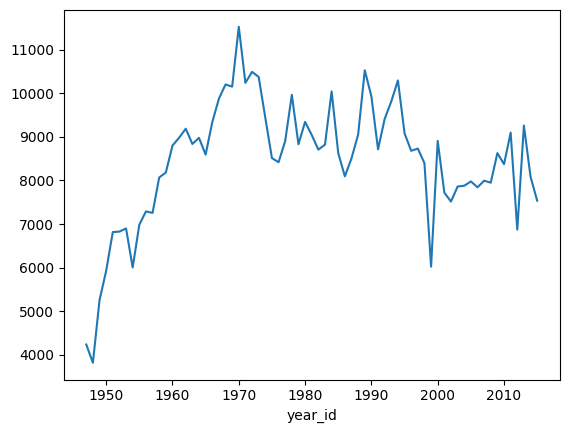

In [52]:
nba[nba["fran_id"] == "Knicks"].groupby("year_id")["pts"].sum().plot()

<Axes: xlabel='fran_id'>

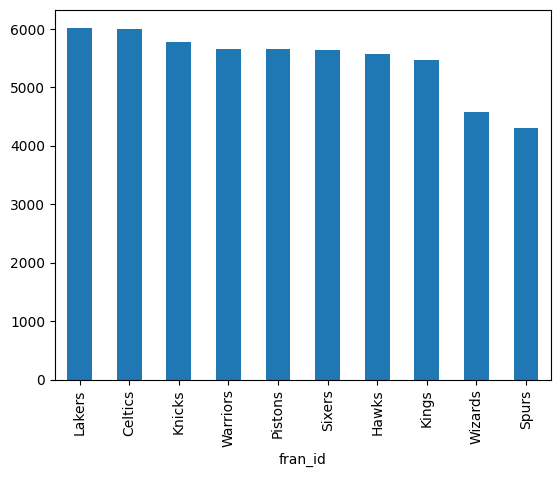

In [53]:
nba["fran_id"].value_counts().head(10).plot(kind="bar")

<Axes: ylabel='count'>

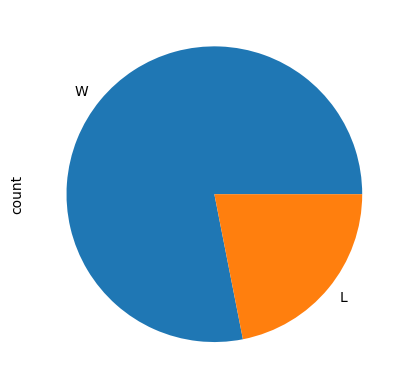

In [54]:
nba[
    (nba["fran_id"] == "Heat") &
    (nba["year_id"] == 2013)
]["game_result"].value_counts().plot(kind="pie")